In [1]:
import pandas as pd

customers = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_customers_dataset.csv")

products = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_products_dataset.csv")

orders = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_orders_dataset.csv")

order_reviews = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_order_reviews_dataset.csv")

order_payments = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_order_payments_dataset.csv")

order_items = pd.read_csv(r"C:\Users\abdel\Downloads\OLIST\olist_order_items_dataset.csv")

In [2]:
def explore_dataset(dataset,name="DATASET"):
    print(f'=' * 20 + f' {name.upper()} ' + f'=' * 20)
    print("HEAD")
    print(dataset.head(1))
    print("-" * 50)

    print("TOTAL NULLS")
    print(dataset.isna().sum())
    print("-" * 50)

    print("SHAPE")
    print(f"Rows:{dataset.shape[0]} | Columns:{dataset.shape[1]}")
    print("-" * 50)

    print("DESCRIBE")
    print(dataset.describe().T)
    print("-" * 50)

    print("COLUMNS")
    print(dataset.columns.tolist())
    print("-" * 50)

    print("DATA TYPES")
    print(dataset.info())
    print("-" * 50)

In [3]:
explore_dataset(orders,name='orders dataset')

==================== ORDERS DATASET ====================
HEAD
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
--------------------------------------------------
TOTAL NULLS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
--------------------------------------------------
SHAPE
Rows:99441 | Columns:8
-----

## Data Parsing

In [4]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_cols:
  orders[col] = pd.to_datetime(orders[col])

## Feature Engineering

In [5]:
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

orders['delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

orders['is_delayed'] = (orders['delay_days'] > 0).astype(int)

## 1. Data Merging & Consolidation
In this step, we merge multiple relational tables (`orders`, `order_items`, `order_reviews`, `customers`, and `products`) into a single master dataset (`master_df`) to enable end-to-end analysis.

In [6]:
master_df = orders.merge(order_items, on='order_id', how='inner')

master_df = master_df.merge(
    order_reviews[['order_id', 'review_score']], on='order_id', how='left'
)

master_df = master_df.merge(
    customers[['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left',
)

master_df = master_df.merge(
    products[['product_id', 'product_category_name', 'product_weight_g']],
    on='product_id',
    how='left',
)

In [7]:
print(master_df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time_days', 'delay_days', 'is_delayed', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'review_score', 'customer_state', 'customer_city',
       'product_category_name', 'product_weight_g'],
      dtype='str')


## 2. Impact of Delivery Delays on Customer Satisfaction
Here we analyze the overall order delay rate and quantify how shipping delays harm customer review scores.

### Key Business Observation:
* **On-time Delivery:** Average review score is high (~4.15 / 5.0).
* **Delayed Delivery:** Average review score drops significantly (~2.26 / 5.0), proving that delay is a major driver of customer dissatisfaction.

In [8]:
overall_delay_rate = master_df['is_delayed'].mean() * 100

avg_score_on_time = master_df[master_df['is_delayed'] == 0]['review_score'].mean()

avg_score_delayed = master_df[master_df['is_delayed'] == 1]['review_score'].mean()

### Visualizing Satisfaction Drop: On-Time vs. Delayed Orders

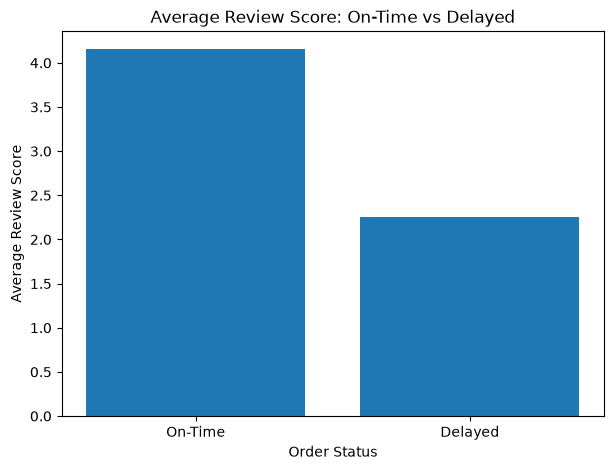

In [9]:
import matplotlib.pyplot as plt

labels = ['On-Time', 'Delayed']
scores = [avg_score_on_time, avg_score_delayed]

plt.figure(figsize=(7, 5))

plt.bar(labels, scores)

plt.xlabel('Order Status')
plt.ylabel('Average Review Score')
plt.title('Average Review Score: On-Time vs Delayed')
plt.show()

In [10]:
print(f'Overall Order Delay Rate: {overall_delay_rate:.2f}%')

print(f'Average Review Score (On-Time): {avg_score_on_time:.2f} / 5.0')

print(f'Average Review Score (Delayed): {avg_score_delayed:.2f} / 5.0')

Overall Order Delay Rate: 6.44%
Average Review Score (On-Time): 4.15 / 5.0
Average Review Score (Delayed): 2.26 / 5.0


## 3. Geographic Bottleneck Analysis (State Level)
To identify where logistical delays are happening, we group the data by customer states and evaluate total orders, delay rates, average freight costs, and delivery times.

In [18]:
state_analysis = (
    master_df.groupby('customer_state').agg(
        total_orders=('order_id' , 'nunique'),
        delay_rate=('is_delayed' , lambda x : x.mean() * 100),
        freight_value=("freight_value" , 'mean'),
        avg_del_days=("delivery_time_days" , 'mean')

    ).reset_index().sort_values(ascending=False,by='delay_rate')
)

print(state_analysis.head())

   customer_state  total_orders  delay_rate  freight_value  avg_del_days
1              AL           411   20.089286      35.744018     23.983759
9              MA           740   17.370326      38.197865     21.139130
24             SE           345   15.844156      36.653169     20.978667
5              CE          1327   13.149022      32.707694     20.525507
16             PI           493   13.075506      39.114954     18.927481


### Top 10 States with Highest Delay Rates
This chart highlights the regional logistics bottlenecks where order delay rates reach up to 20%.

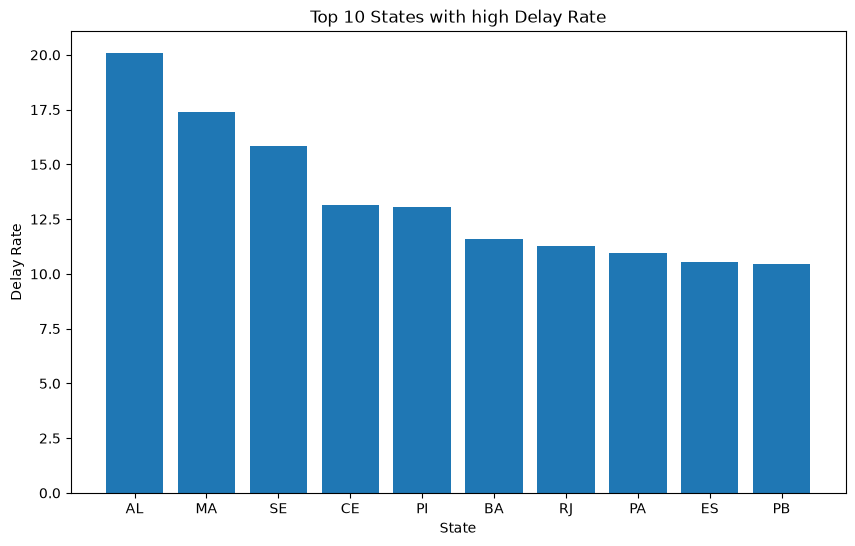

In [26]:
top_10_states = state_analysis.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_10_states['customer_state'],
    top_10_states['delay_rate']
)

plt.xlabel("State")
plt.ylabel("Delay Rate")
plt.title("Top 10 States with high Delay Rate")
plt.show()

## Freight Cost vs. Delivery Delay Analysis (Binning)
To evaluate whether higher shipping costs correlate with logistical delays, we segment orders into three equal freight tiers using quantile binning (`pd.qcut`) and evaluate total orders, delay rates, and average delivery times per group.

In [28]:
master_df['freight_group'] = pd.qcut(
    master_df['freight_value'],
    q=3,
    labels=['Low Freight', 'Medium Freight', 'High Freight']
)

freight_analysis = (
    master_df.groupby("freight_group").agg(
        total_orders=("order_id",'nunique'),
        delay_rate=("is_delayed" , lambda x:x.mean() * 100),
        avg_del_days=('delivery_time_days', 'mean')
    ).reset_index()
)

print(freight_analysis.head())

    freight_group  total_orders  delay_rate  avg_del_days
0     Low Freight         32689    4.343688      7.888664
1  Medium Freight         33459    7.007786     13.165932
2    High Freight         33869    7.964273     15.001358


## Visualizing High-Risk Logistics States
To highlight the primary geographical bottlenecks, we plot the top 10 Brazilian states with the highest order delay rates, illustrating where logistical infrastructure faces the greatest strain.

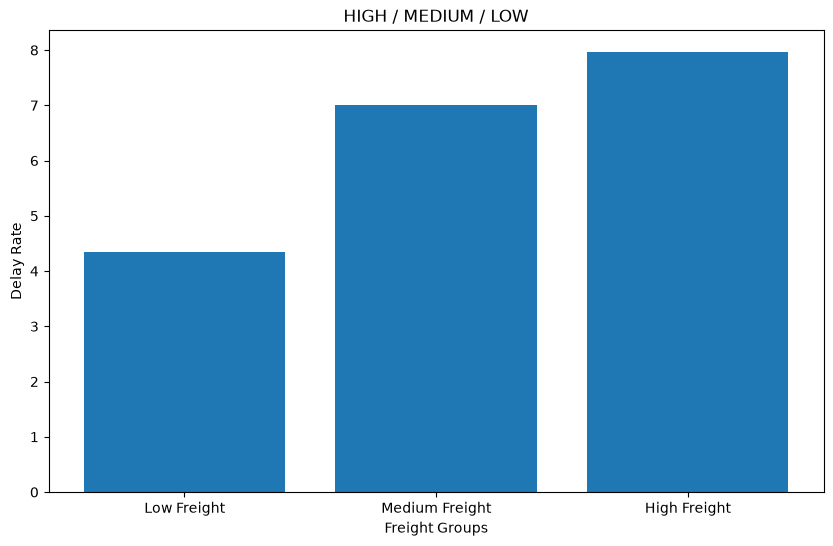

In [27]:
freight = freight_analysis.head()

plt.figure(figsize=(10,6))

plt.bar(
    freight_analysis['freight_group'],
    freight_analysis['delay_rate']
)

plt.xlabel("Freight Groups")
plt.ylabel("Delay Rate")
plt.title("HIGH / MEDIUM / LOW")
plt.show()

### Average Delivery Days in High-Delay States
Analyzing average delivery duration in days for the most affected regions to understand shipping timelines.

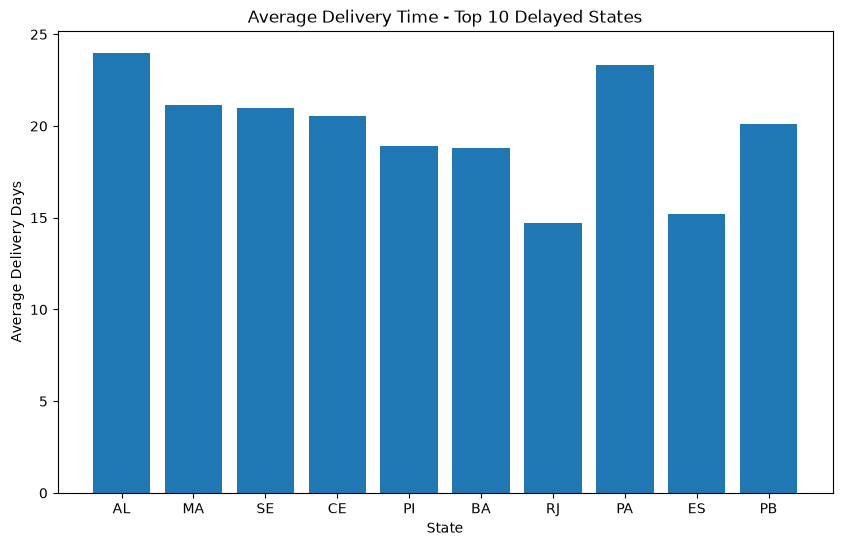

In [13]:
top_10_states = state_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_states['customer_state'],
    top_10_states['avg_del_days']
)

plt.xlabel('State')
plt.ylabel('Average Delivery Days')
plt.title('Average Delivery Time - Top 10 Delayed States')
plt.show()

## 4. Key Takeaways & Proposed HVIA AI Solution

### Business Takeaways

1. **Delivery Delays Are Associated with Lower Customer Satisfaction:**
   Delayed orders received substantially lower average review scores than on-time orders, with scores of **2.26/5** versus **4.15/5** respectively.

2. **Regional Variation in Delivery Performance:**
   Delivery delay rates vary significantly across customer states. In our analysis, **AL (20.09%), MA (17.37%), and SE (15.84%)** had the highest observed delay rates among the states analyzed.

3. **Higher Freight Is Associated with Longer Delivery Times and More Delays:**
   Delay rates increased from **4.34%** for low-freight orders to **7.96%** for high-freight orders. Average delivery time also increased from **7.89 days** to **15.00 days**.

### Proposed AI / ML Solution

**Predictive Delivery Risk Engine:**
HVIA could develop a machine learning system that predicts the probability of an order being delayed using available order, geographic, product, and freight-related characteristics.

The system would identify **high-risk orders and regions early**, allowing Olist to prioritize monitoring, investigate potential logistics issues, and take preventive action before delays negatively affect the customer experience.

**Future Extension — Carrier Optimization:**
If Olist provides carrier-level operational data, the prediction engine could be extended to incorporate **carrier performance** and support data-driven carrier selection or routing decisions.
